In [1]:
import os
import torch
from PIL import Image
import my_models_mae
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

In [2]:
transform_train = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=0.17597473, std=0.23851053),
    ]
)

# CHANGED loader
def pil_loader_grey(path: str) -> Image:
    return Image.open(path)

dataset_train = datasets.ImageFolder(
    os.path.join("/scratch/hellgoth/data/spheres_small_2d_png/", "train"),
    loader=pil_loader_grey,
    transform=transform_train,
)
sample = dataset_train[0][0]
sample.shape, sample.min(), sample.max()

(torch.Size([1, 224, 224]), tensor(-0.7378), tensor(1.5476))

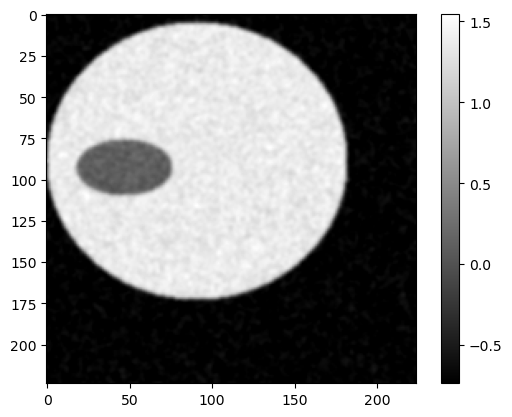

In [3]:
plt.imshow(sample[0], cmap="gray")
plt.colorbar()
plt.show()

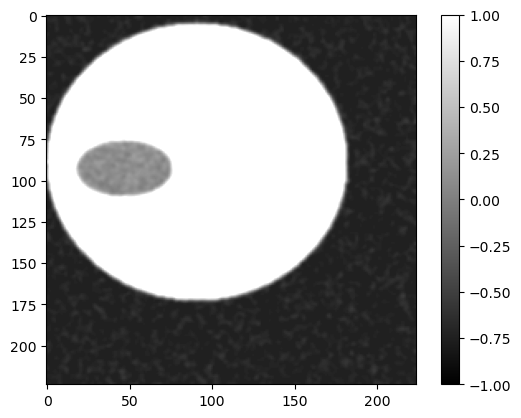

In [4]:
plt.imshow(sample[0], cmap="gray", vmin=-1, vmax=1)
plt.colorbar()
plt.show()

In [5]:
# normal MAE, single channel, no norm pix loss

In [6]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres_maester6/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=False,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [ ]:
latent, mask, ids_restore = model.forward_encoder(sample[None], 0.0)
pred = model.forward_decoder(latent, ids_restore)
recon = model.unpatchify(pred)
latent.shape, mask.shape, ids_restore.shape, pred.shape, recon.shape

(torch.Size([1, 197, 768]),
 torch.Size([1, 196]),
 torch.Size([1, 196]),
 torch.Size([1, 196, 256]),
 torch.Size([1, 1, 224, 224]))

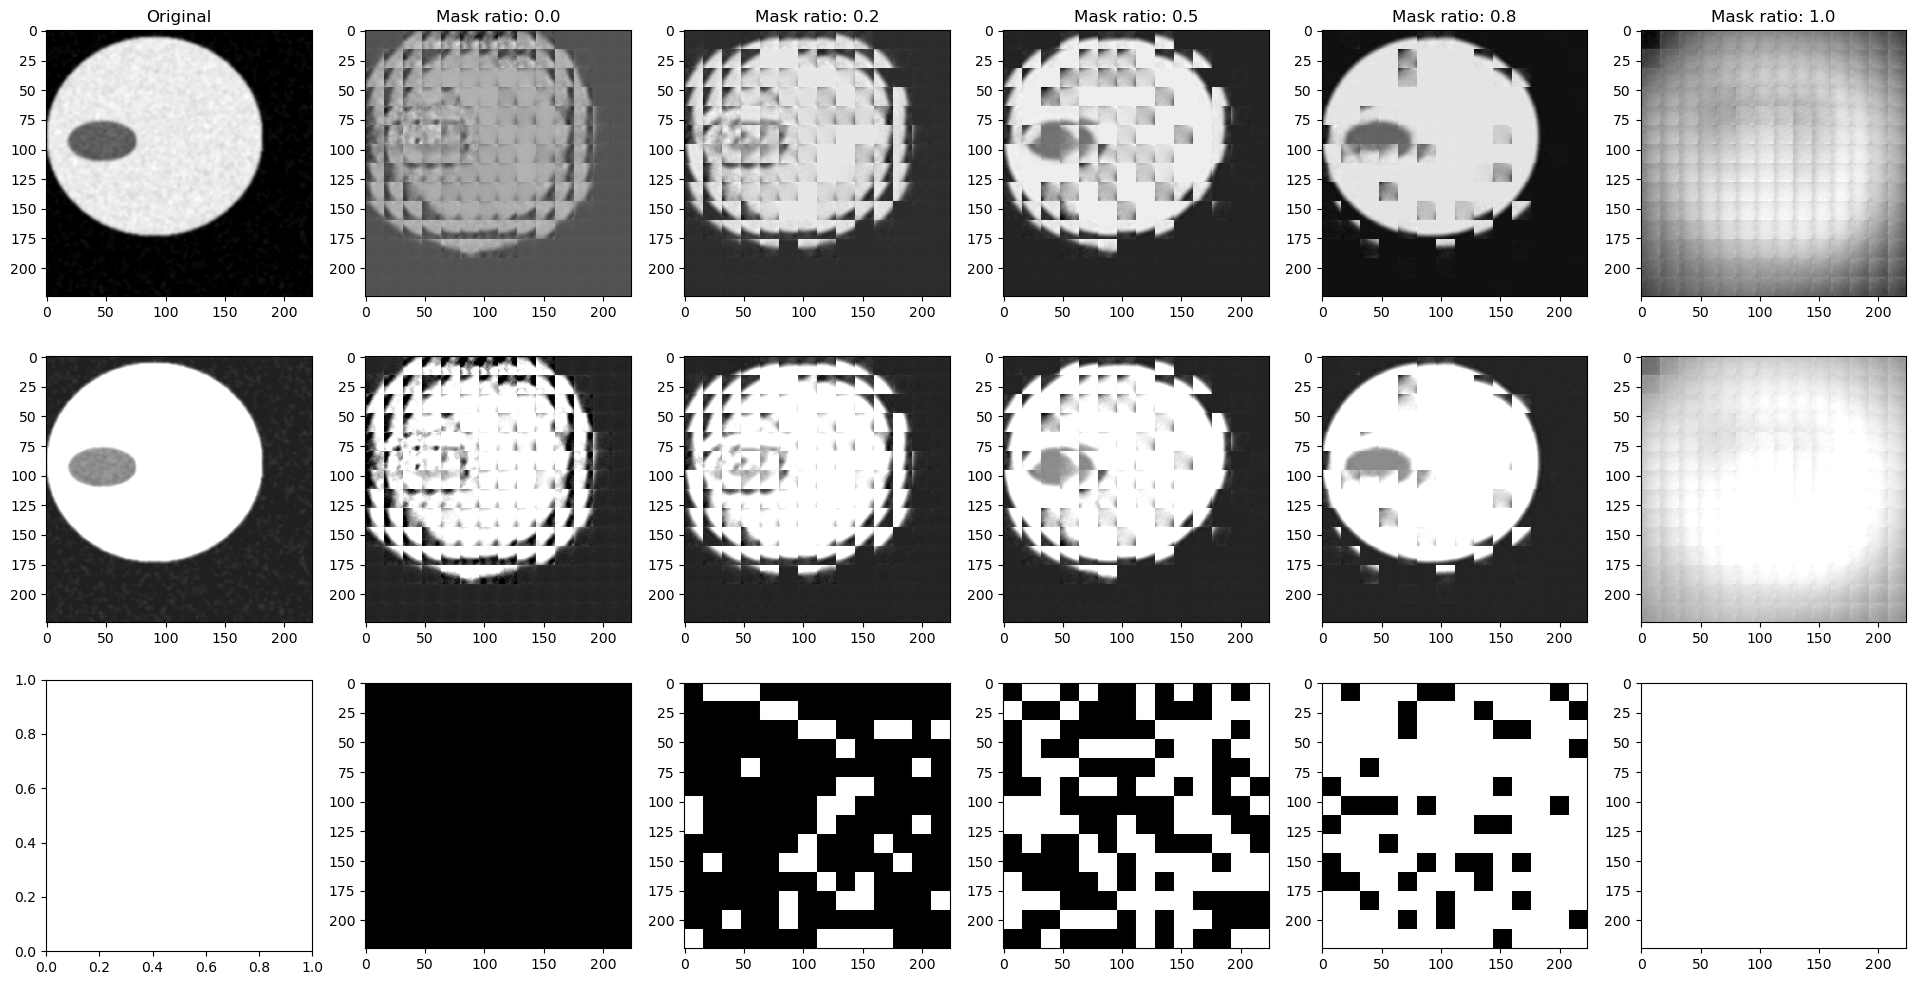

In [28]:
fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes[0, 0].imshow(sample[0], cmap="gray")
axes[0, 0].set_title("Original")
axes[1, 0].imshow(sample[0], cmap="gray", vmin=-1, vmax=1)
for i, mask_ratio in enumerate([0.0, 0.2, 0.5, 0.8, 1.0]):
    latent, mask, ids_restore = model.forward_encoder(sample[None], mask_ratio)
    pred = model.forward_decoder(latent, ids_restore)
    recon = model.unpatchify(pred)
    mask_img = model.unpatchify(mask[..., None].repeat(1, 1, 256))
    axes[0, i+1].imshow(recon[0, 0].detach(), cmap="gray")
    axes[0, i+1].set_title(f"Mask ratio: {mask_ratio}")
    axes[1, i+1].imshow(recon[0, 0].detach(), cmap="gray", vmin=-1, vmax=1)
    axes[2, i+1].imshow(mask_img[0, 0].detach(), cmap="gray", vmin=0, vmax=1)
plt.show()

In [ ]:
# normal MAE, single channel, no norm pix loss, loss on all patches

In [24]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres_maester7/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=True,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

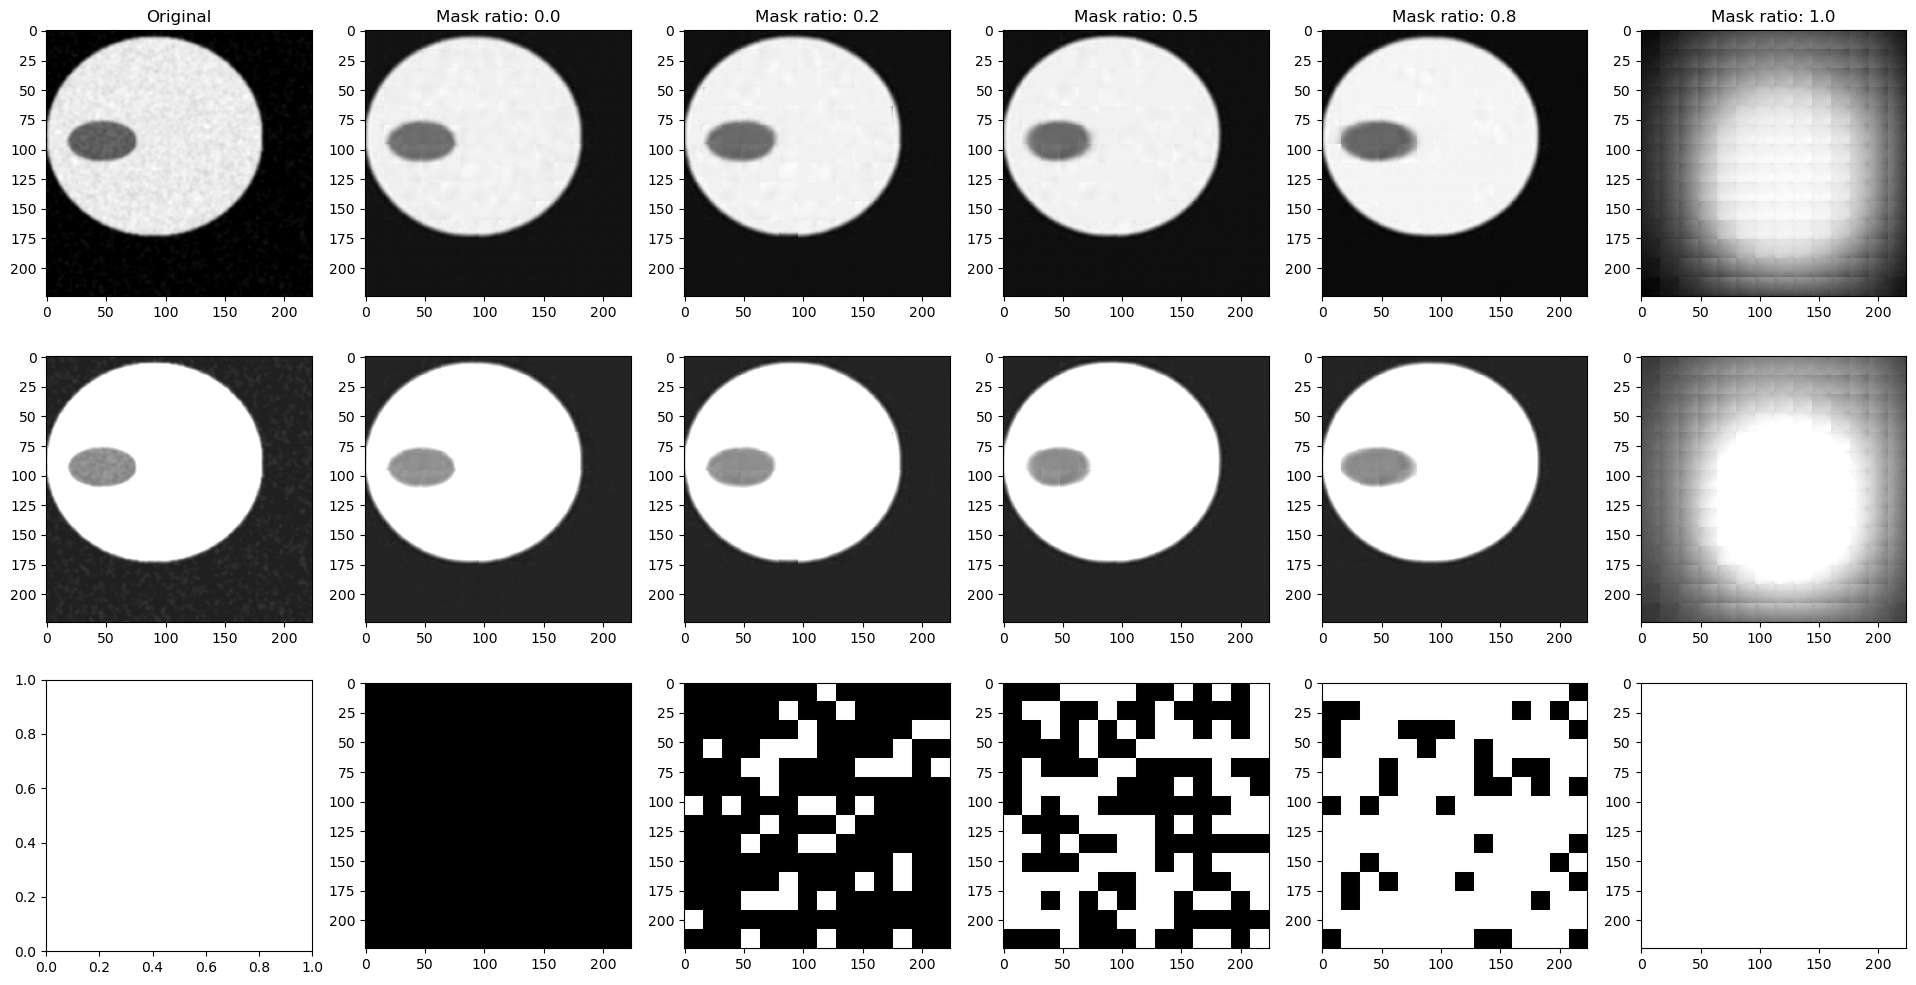

In [26]:
fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes[0, 0].imshow(sample[0], cmap="gray")
axes[0, 0].set_title("Original")
axes[1, 0].imshow(sample[0], cmap="gray", vmin=-1, vmax=1)
for i, mask_ratio in enumerate([0.0, 0.2, 0.5, 0.8, 1.0]):
    latent, mask, ids_restore = model.forward_encoder(sample[None], mask_ratio)
    pred = model.forward_decoder(latent, ids_restore)
    recon = model.unpatchify(pred)
    mask_img = model.unpatchify(mask[..., None].repeat(1, 1, 256))
    axes[0, i+1].imshow(recon[0, 0].detach(), cmap="gray")
    axes[0, i+1].set_title(f"Mask ratio: {mask_ratio}")
    axes[1, i+1].imshow(recon[0, 0].detach(), cmap="gray", vmin=-1, vmax=1)
    axes[2, i+1].imshow(mask_img[0, 0].detach(), cmap="gray", vmin=0, vmax=1)
plt.show()